# Stock Portfolio Monte Carlo Simulation

In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import datetime as dt 
import yfinance as yf 

## Data Ingestion

In [40]:
tickers = ['^GSPC', 'TSLA', 'NFLX']

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=300)

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
data.head()

[*********************100%***********************]  3 of 3 completed


Ticker,NFLX,TSLA,^GSPC
Date,,,
2025-04-07,86.782997,233.289993,5062.250000
2025-04-08,87.040001,221.860001,4982.770020
2025-04-09,94.546997,272.200012,5456.899902
2025-04-10,92.116997,252.399994,5268.049805
2025-04-11,91.829002,252.309998,5363.359863


## Computing Mean returns, standard deviation and covariance matrix

In [41]:
returns = np.log(data / data.shift(1))

mean_returns = returns.mean()
std_dev_returns = returns.std()
cov_matrix = returns.cov()

print("Mean returns:", mean_returns)
print("Standard Deviation:", std_dev_returns)
print("Covariance Matrix:", cov_matrix)

Mean returns: Ticker
NFLX    -0.000189
TSLA     0.002988
^GSPC    0.001538
dtype: float64
Standard Deviation: Ticker
NFLX     0.019301
TSLA     0.035622
^GSPC    0.010416
dtype: float64
Covariance Matrix: Ticker      NFLX      TSLA     ^GSPC
Ticker                              
NFLX    0.000373  0.000125  0.000070
TSLA    0.000125  0.001269  0.000246
^GSPC   0.000070  0.000246  0.000108


In [42]:
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)

[0.33333333 0.33333333 0.33333333]


## Monte Carlo Method

In [43]:
simulations = 1000
T= 300 # days
initial_portfolio_value = 100000

mean_matrix = np.full(shape=(T, len(weights)), fill_value= mean_returns)
portfolio_sims = np.full(shape=(T, simulations), fill_value=0.0)

for i in range(0, simulations): # Assuming daily returns are distributed by a Multivariate Normal Distribution: R_t - MVN(mean, cov_matrix)
    Z = np.random.normal(size = (T, len(weights)))
    L = np.linalg.cholesky(cov_matrix)
    daily_returns = mean_matrix.T + np.inner(L, Z)
    portfolio_sims[:, i] = np.cumprod(np.inner(weights, daily_returns.T)+1)*initial_portfolio_value

print(f"Initial portfolio value: {initial_portfolio_value:,.2f}")
print(f"Expected final value (mean): {portfolio_sims.mean():,.2f}")
print(f"Median final value: {np.median(portfolio_sims):,.2f}")

Initial portfolio value: 100,000.00
Expected final value (mean): 125,866.91
Median final value: 118,466.65


## Plotting

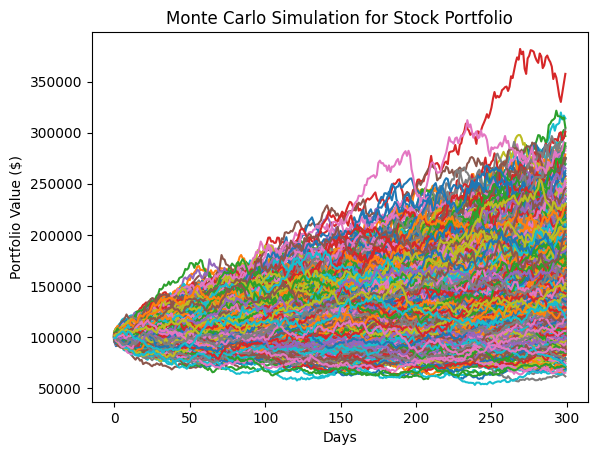

In [44]:
plt.plot(portfolio_sims)
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Days")
plt.title("Monte Carlo Simulation for Stock Portfolio")
plt.show()